# PK Figure -> CSV

Extract observed data points from pharmacokinetic time-concentration plots and save them to a CSV that can later be re-plotted.

**Workflow**

1. Inspect the image.
2. Calibrate the axes by clicking two known x-tick locations and two known y-tick locations (log or linear).
3. For each trajectory in the figure, click on the centre of every observed point. Right-click to undo the last click.
4. Save the result to a tidy CSV: `trajectory, x, y`.
5. Re-plot from the CSV to verify the extraction.

**Backend.** This notebook uses interactive matplotlib clicks. Install `ipympl` (`pip install ipympl`) and keep the `%matplotlib widget` magic below. If you prefer a separate window, swap it for `%matplotlib qt` or `%matplotlib tk`.

In [1]:
%matplotlib widget
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

## The extractor

A small state machine around a matplotlib figure: `calibrate` records two reference clicks per axis, `start_trajectory` / `finish_trajectory` collect the observed points for one curve, and `save_csv` / `replot` produce the final artefacts.

Pixel-to-data conversion handles linear and log axes. For log axes, both reference values must be strictly positive.

In [2]:
class PKFigureExtractor:
    """Click-based extractor for time-concentration plots."""

    def __init__(self, image_path, x_log=False, y_log=False):
        self.image_path = Path(image_path)
        self.img = np.array(Image.open(self.image_path).convert("RGB"))
        self.x_log = x_log
        self.y_log = y_log
        self.x_refs = None  # [(pixel_x, data_x), (pixel_x, data_x)]
        self.y_refs = None  # [(pixel_y, data_y), (pixel_y, data_y)]
        self.trajectories = {}  # name -> list of (x_data, y_data)
        self._fig = None
        self._ax = None
        self._cid = None
        self._mode = None
        self._pending = []
        self._pending_meta = None

    # ---------- figure helpers ----------
    def _open(self, title):
        if self._fig is not None:
            plt.close(self._fig)
        self._fig, self._ax = plt.subplots(figsize=(11, 8))
        self._ax.imshow(self.img)
        self._ax.set_xticks([]); self._ax.set_yticks([])
        self._ax.set_title(title, fontsize=11)
        return self._fig, self._ax

    def _connect(self, handler):
        if self._cid is not None and self._fig is not None:
            self._fig.canvas.mpl_disconnect(self._cid)
        self._cid = self._fig.canvas.mpl_connect("button_press_event", handler)

    # ---------- coordinate conversion ----------
    def pixel_to_data(self, px, py):
        if self.x_refs is None or self.y_refs is None:
            raise RuntimeError("Axes not calibrated yet.")
        (xpa, xva), (xpb, xvb) = self.x_refs
        if self.x_log:
            la, lb = np.log10(xva), np.log10(xvb)
            x = 10 ** (la + (px - xpa) * (lb - la) / (xpb - xpa))
        else:
            x = xva + (px - xpa) * (xvb - xva) / (xpb - xpa)
        (ypa, yva), (ypb, yvb) = self.y_refs
        if self.y_log:
            la, lb = np.log10(yva), np.log10(yvb)
            y = 10 ** (la + (py - ypa) * (lb - la) / (ypb - ypa))
        else:
            y = yva + (py - ypa) * (yvb - yva) / (ypb - ypa)
        return x, y

    def _data_to_pixel(self, x, y):
        (xpa, xva), (xpb, xvb) = self.x_refs
        if self.x_log:
            la, lb = np.log10(xva), np.log10(xvb)
            px = xpa + (np.log10(x) - la) * (xpb - xpa) / (lb - la)
        else:
            px = xpa + (x - xva) * (xpb - xpa) / (xvb - xva)
        (ypa, yva), (ypb, yvb) = self.y_refs
        if self.y_log:
            la, lb = np.log10(yva), np.log10(yvb)
            py = ypa + (np.log10(y) - la) * (ypb - ypa) / (lb - la)
        else:
            py = ypa + (y - yva) * (ypb - ypa) / (yvb - yva)
        return px, py

    # ---------- step 1: inspect ----------
    def show(self):
        self._open(f"{self.image_path.name}  (x_log={self.x_log}, y_log={self.y_log})")

    # ---------- step 2: calibrate ----------
    def calibrate(self, x_refs, y_refs):
        """Click 4 reference points in order: x[0], x[1], y[0], y[1]."""
        for is_log, refs, name in [(self.x_log, x_refs, "x"), (self.y_log, y_refs, "y")]:
            if is_log and (refs[0] <= 0 or refs[1] <= 0):
                raise ValueError(f"{name}-axis is log: reference values must be > 0.")
        self._mode = "calibrate"
        self._pending = []
        order = [f"x = {x_refs[0]}", f"x = {x_refs[1]}",
                 f"y = {y_refs[0]}", f"y = {y_refs[1]}"]
        fig, ax = self._open(f"Calibrate (1/4): click {order[0]}")

        def on_click(event):
            if event.inaxes != ax or event.xdata is None:
                return
            i = len(self._pending)
            self._pending.append((event.xdata, event.ydata))
            colour = "tab:red" if i < 2 else "tab:blue"
            ax.plot(event.xdata, event.ydata, marker="+", ms=18, mew=2.4, color=colour)
            ax.annotate(order[i], (event.xdata, event.ydata),
                        xytext=(8, -8), textcoords="offset points",
                        fontsize=9, color=colour)
            if i + 1 < 4:
                ax.set_title(f"Calibrate ({i+2}/4): click {order[i+1]}", fontsize=11)
            else:
                xpa, _ = self._pending[0]
                xpb, _ = self._pending[1]
                _, ypa = self._pending[2]
                _, ypb = self._pending[3]
                self.x_refs = [(xpa, x_refs[0]), (xpb, x_refs[1])]
                self.y_refs = [(ypa, y_refs[0]), (ypb, y_refs[1])]
                ax.set_title("Axes calibrated -- ready to extract trajectories.",
                             fontsize=11, color="tab:green")
                fig.canvas.mpl_disconnect(self._cid)
                self._cid = None
                self._mode = None
            fig.canvas.draw_idle()

        self._connect(on_click)

    # ---------- step 3: trajectories ----------
    def start_trajectory(self, name):
        if self.x_refs is None or self.y_refs is None:
            raise RuntimeError("Calibrate the axes first.")
        self._mode = "trajectory"
        self._pending = []
        self._pending_meta = name
        fig, ax = self._open(
            f"Trajectory '{name}': left-click each observed point, right-click to undo. "
            f"Then run finish_trajectory()."
        )
        for tname, pts in self.trajectories.items():
            xs, ys = zip(*[self._data_to_pixel(x, y) for x, y in pts])
            ax.plot(xs, ys, "o", ms=5, mfc="none", mec="gray", alpha=0.4)

        def redraw():
            ax.cla()
            ax.imshow(self.img)
            ax.set_xticks([]); ax.set_yticks([])
            for tname, pts in self.trajectories.items():
                xs, ys = zip(*[self._data_to_pixel(x, y) for x, y in pts])
                ax.plot(xs, ys, "o", ms=5, mfc="none", mec="gray", alpha=0.4)
            if self._pending:
                xs, ys = zip(*self._pending)
                ax.plot(xs, ys, "o", ms=8, mfc="none", mec="red", mew=2)
            ax.set_title(
                f"Trajectory '{name}': {len(self._pending)} points "
                f"(right-click undo, then finish_trajectory())", fontsize=11,
            )
            fig.canvas.draw_idle()

        def on_click(event):
            if event.inaxes != ax or event.xdata is None:
                return
            if event.button == 3:
                if self._pending:
                    self._pending.pop()
                    redraw()
                return
            self._pending.append((event.xdata, event.ydata))
            ax.plot(event.xdata, event.ydata, "o", ms=8, mfc="none", mec="red", mew=2)
            ax.set_title(
                f"Trajectory '{name}': {len(self._pending)} points "
                f"(right-click undo, then finish_trajectory())", fontsize=11,
            )
            fig.canvas.draw_idle()

        self._connect(on_click)

    def finish_trajectory(self):
        if self._mode != "trajectory":
            raise RuntimeError("No trajectory in progress.")
        name = self._pending_meta
        pts = sorted(
            (self.pixel_to_data(px, py) for px, py in self._pending),
            key=lambda p: p[0],
        )
        self.trajectories[name] = pts
        if self._cid is not None:
            self._fig.canvas.mpl_disconnect(self._cid)
            self._cid = None
        self._ax.set_title(
            f"Trajectory '{name}' captured: {len(pts)} points.",
            color="tab:green", fontsize=11,
        )
        self._fig.canvas.draw_idle()
        self._mode = None
        return pts

    # ---------- step 4 / 5: export and verify ----------
    def to_dataframe(self):
        rows = [
            {"trajectory": name, "x": x, "y": y}
            for name, pts in self.trajectories.items()
            for x, y in pts
        ]
        return pd.DataFrame(rows)

    def save_csv(self, path):
        df = self.to_dataframe()
        df.to_csv(path, index=False)
        return df

    def replot(self, ax=None, x_label="x", y_label="y"):
        if ax is None:
            _, ax = plt.subplots(figsize=(8, 6))
        for name, pts in self.trajectories.items():
            xs, ys = zip(*pts)
            ax.plot(xs, ys, "o-", label=name, alpha=0.85)
        if self.x_log:
            ax.set_xscale("log")
        if self.y_log:
            ax.set_yscale("log")
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.grid(True, which="both", ls=":", alpha=0.5)
        ax.legend(fontsize=8, loc="best")
        ax.set_title("Re-plotted from extracted CSV")
        return ax

## 1. Configure and inspect

Pick the image and declare the axis scales. The two example figures in this repo:

| File | x-axis | y-axis |
|---|---|---|
| `Plasma-concentration-time-curves-of-paclitaxel-at-each-dose-level.webp` | linear (0 - 50 hr) | log (1 - 10,000 ug/L) |
| `Screenshot 2026-05-07 at 3.46.48 PM.png` | log (0.25 - 32 h) | linear (0.0 - 1.0 ug/mL) |


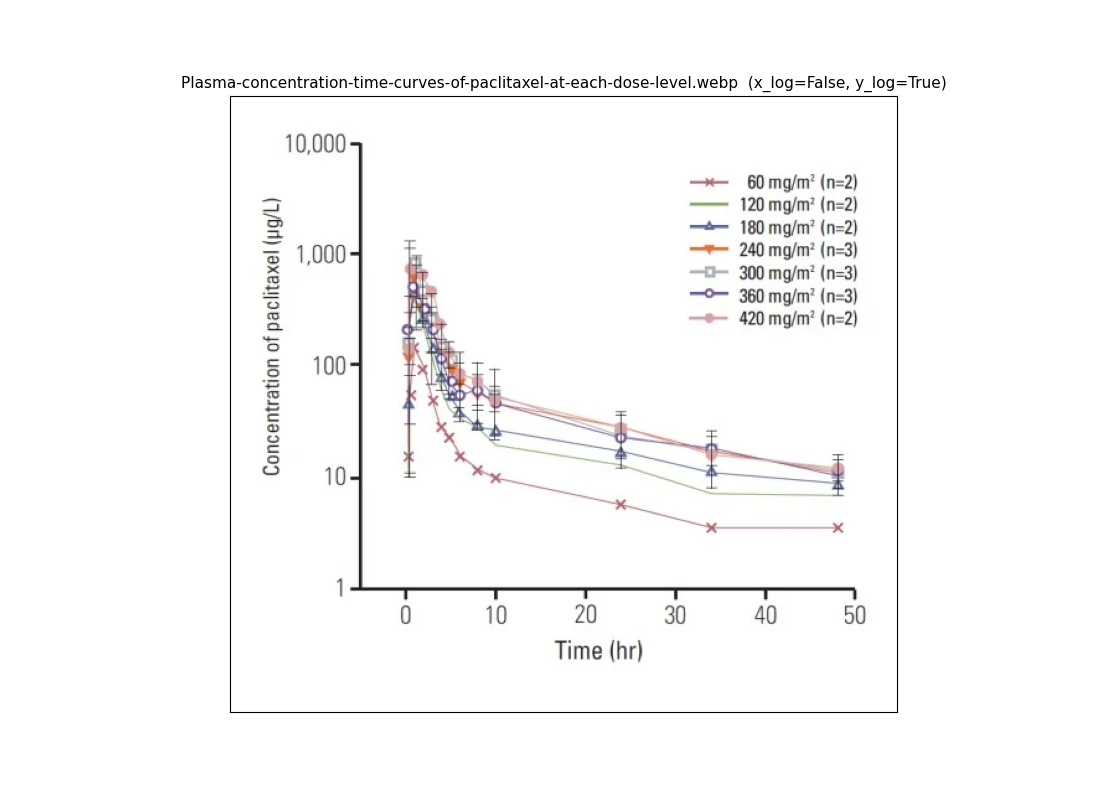

In [3]:
IMAGE_PATH = "example_images/Plasma-concentration-time-curves-of-paclitaxel-at-each-dose-level.webp"
X_LOG = False
Y_LOG = True
OUTPUT_CSV = "extracted_paclitaxel.csv"

extractor = PKFigureExtractor(IMAGE_PATH, x_log=X_LOG, y_log=Y_LOG)
extractor.show()

## 2. Calibrate the axes

Pass two known tick locations on each axis. After running this cell, click the figure four times in this exact order:

1. The point on the x-axis at `x_refs[0]`
2. The point on the x-axis at `x_refs[1]`
3. The point on the y-axis at `y_refs[0]`
4. The point on the y-axis at `y_refs[1]`

Pick references that are far apart and unambiguously labelled (e.g. major gridlines). For log axes both values must be > 0.

Suggested values:
- Paclitaxel image: `x_refs=(0, 50)`, `y_refs=(1, 10000)`
- Cisplatin image: `x_refs=(0.5, 16)`, `y_refs=(0.0, 1.0)`

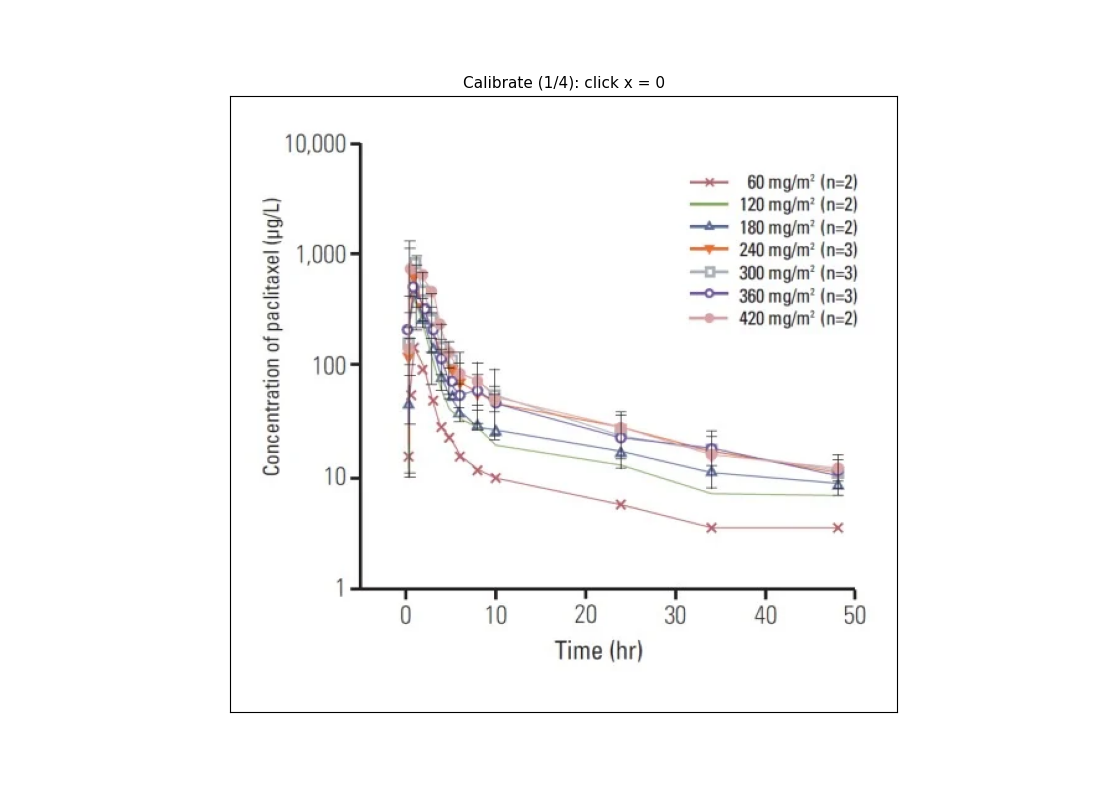

In [6]:
extractor.calibrate(x_refs=(0, 50), y_refs=(1, 10_000))

## 3. Extract each trajectory

For every curve in the figure:

1. Run `start_trajectory("<name>")`. The figure re-opens; previously captured points are shown as faint grey rings.
2. Left-click the centre of each observed marker. Right-click to undo the last click.
3. Run `finish_trajectory()` to commit the curve.

Repeat for every trajectory in the legend. Duplicate the cells below as needed.

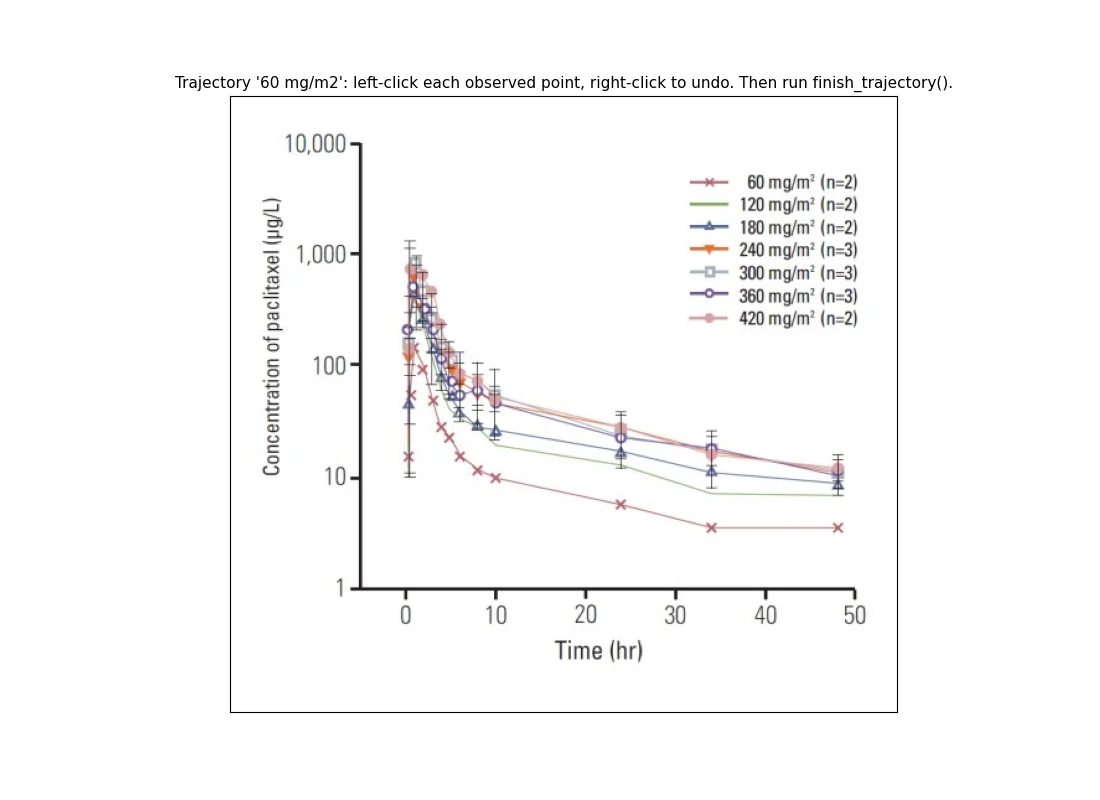

In [7]:
extractor.start_trajectory("60 mg/m2")

In [8]:
extractor.finish_trajectory()

[(np.float64(4.757085020242918), np.float64(125.63166024741201)),
 (np.float64(4.9595141700404906), np.float64(15.459277364194785)),
 (np.float64(5.161943319838055), np.float64(58.31305113526228)),
 (np.float64(5.465587044534413), np.float64(157.8331405652118)),
 (np.float64(6.275303643724695), np.float64(95.93608287093141)),
 (np.float64(7.388663967611334), np.float64(52.56791122018422)),
 (np.float64(8.198380566801623), np.float64(29.408201705870653)),
 (np.float64(9.109311740890691), np.float64(22.9276931286565)),
 (np.float64(10.121457489878544), np.float64(15.141893253043527)),
 (np.float64(11.842105263157892), np.float64(12.052609368708431)),
 (np.float64(13.663967611336036), np.float64(10.20960662306046)),
 (np.float64(26.315789473684205), np.float64(5.7115864781264305)),
 (np.float64(35.526315789473685), np.float64(3.6946012051993025)),
 (np.float64(48.481781376518214), np.float64(3.544455673970433))]

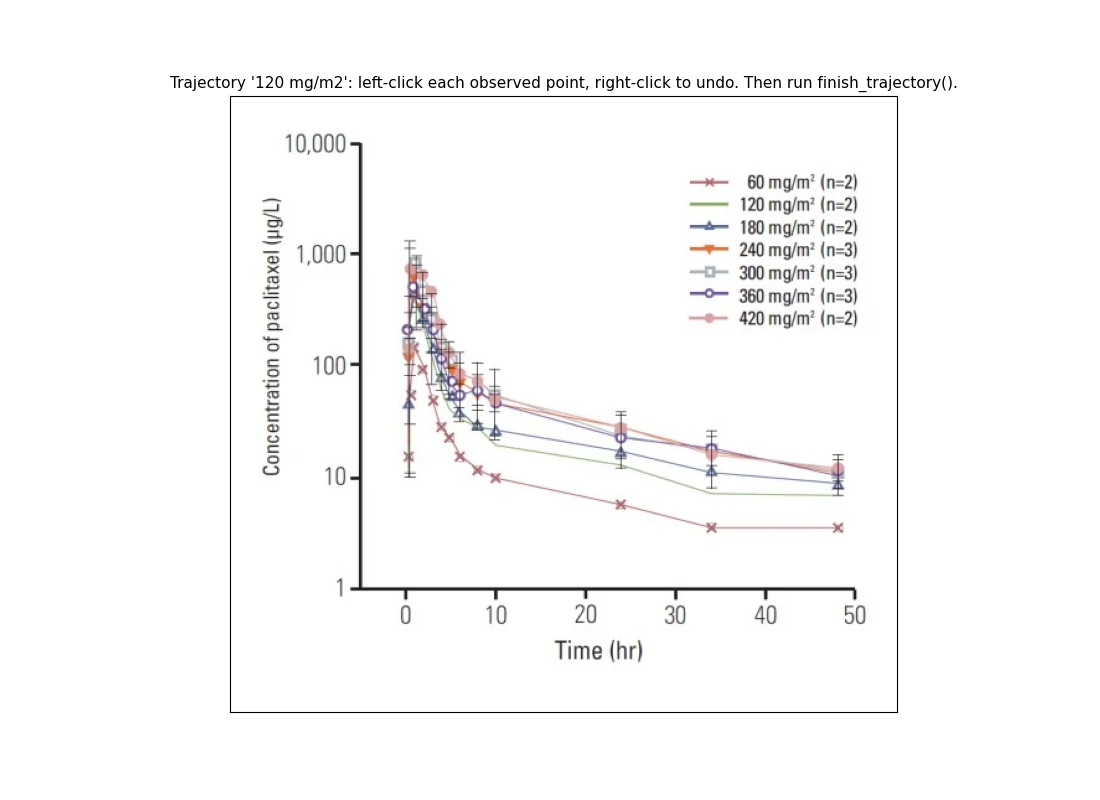

In [9]:
extractor.start_trajectory("120 mg/m2")

In [10]:
extractor.finish_trajectory()

[(np.float64(5.364372469635627), np.float64(369.46012051993023)),
 (np.float64(6.680161943319839), np.float64(186.324631193156)),
 (np.float64(7.793522267206479), np.float64(100.0)),
 (np.float64(8.906882591093119), np.float64(45.462954695324015)),
 (np.float64(10.02024291497976), np.float64(36.18749812411282)),
 (np.float64(11.842105263157892), np.float64(29.408201705870653)),
 (np.float64(13.765182186234824), np.float64(19.828839491270703)),
 (np.float64(26.417004048583003), np.float64(12.826498305280598)),
 (np.float64(35.526315789473685), np.float64(7.1755609189369265)),
 (np.float64(48.68421052631579), np.float64(6.74262224177834))]

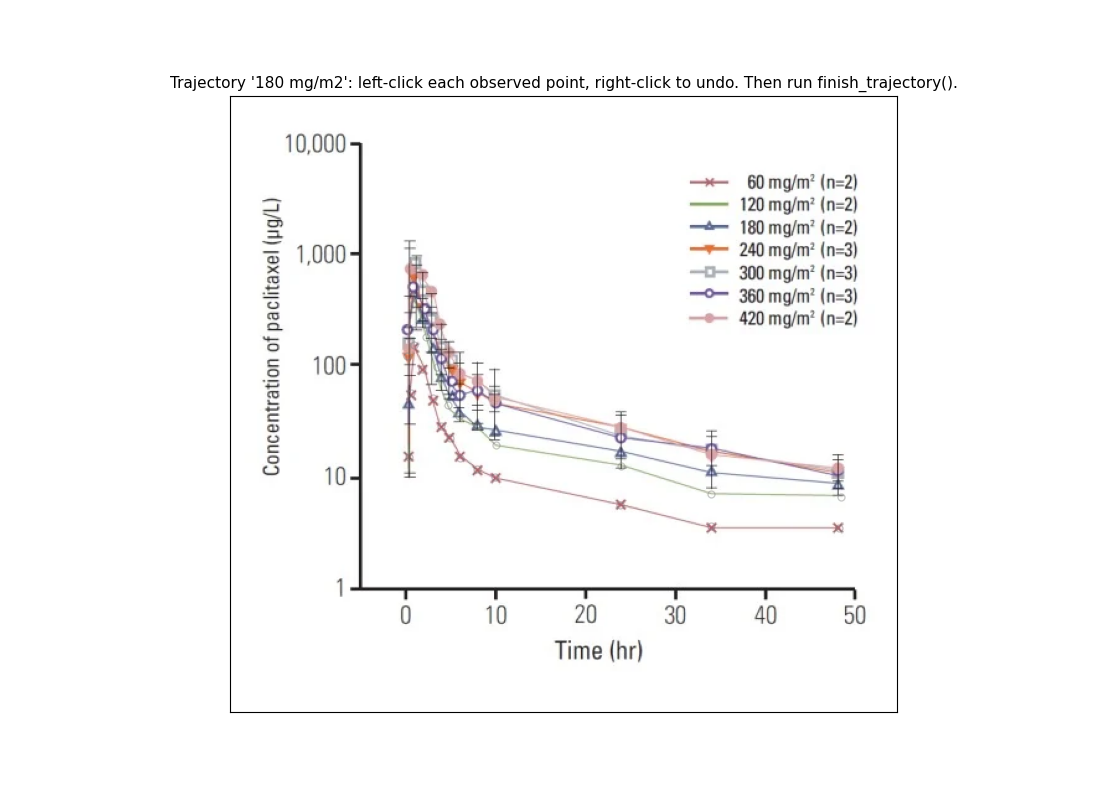

In [11]:
extractor.start_trajectory("180 mg/m2")

In [12]:
extractor.finish_trajectory()

[(np.float64(4.757085020242918), np.float64(46.41588833612782)),
 (np.float64(5.465587044534413), np.float64(445.295850994266)),
 (np.float64(6.376518218623481), np.float64(259.6655972934872)),
 (np.float64(7.489878542510121), np.float64(154.5927736419477)),
 (np.float64(8.502024291497975), np.float64(77.96360130405233)),
 (np.float64(9.311740890688263), np.float64(57.11586478126435)),
 (np.float64(10.02024291497976), np.float64(40.1424249049932)),
 (np.float64(11.740890688259107), np.float64(29.408201705870653)),
 (np.float64(13.663967611336036), np.float64(25.96655972934871)),
 (np.float64(26.417004048583003), np.float64(16.451905877536618)),
 (np.float64(35.72874493927125), np.float64(10.865157746525378)),
 (np.float64(48.38056680161944), np.float64(8.64842327573172))]

## 4. Save to CSV

In [13]:
df = extractor.save_csv(OUTPUT_CSV)
print(f"Saved {len(df)} points across {df['trajectory'].nunique()} trajectories to {OUTPUT_CSV}")
df.head(20)

Saved 36 points across 3 trajectories to extracted_paclitaxel.csv


,trajectory,x,y
0,60 mg/m2,4.757085,125.631660
1,60 mg/m2,4.959514,15.459277
2,60 mg/m2,5.161943,58.313051
3,60 mg/m2,5.465587,157.833141
4,60 mg/m2,6.275304,95.936083
5,60 mg/m2,7.388664,52.567911
6,60 mg/m2,8.198381,29.408202
7,60 mg/m2,9.109312,22.927693
8,60 mg/m2,10.121457,15.141893
9,60 mg/m2,11.842105,12.052609


## 5. Re-plot from the CSV

Round-trip check: load the CSV back from disk and reconstruct the plot. If the calibration was right, the reconstructed plot should look like the original.

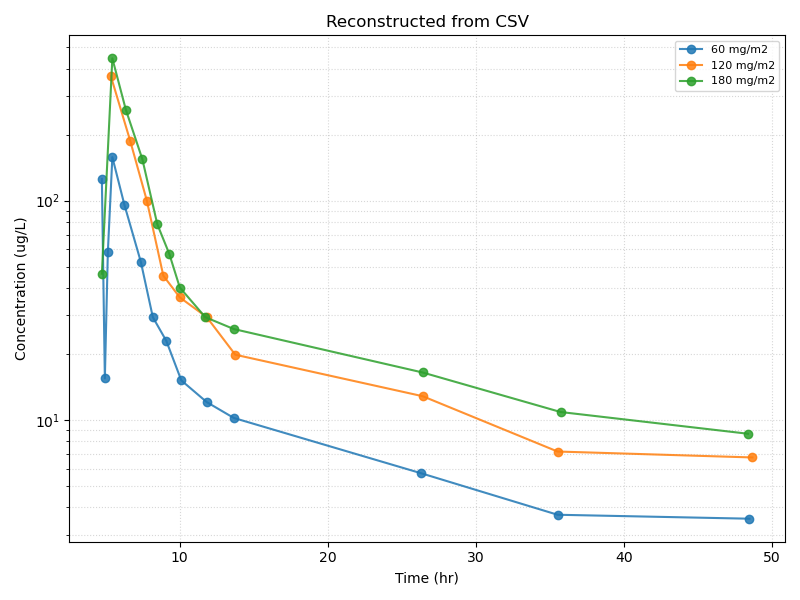

In [14]:
loaded = pd.read_csv(OUTPUT_CSV)

fig, ax = plt.subplots(figsize=(8, 6))
for name, group in loaded.groupby("trajectory", sort=False):
    ax.plot(group["x"], group["y"], "o-", label=name, alpha=0.85)
if X_LOG:
    ax.set_xscale("log")
if Y_LOG:
    ax.set_yscale("log")
ax.set_xlabel("Time (hr)")
ax.set_ylabel("Concentration (ug/L)")
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend(fontsize=8, loc="best")
ax.set_title("Reconstructed from CSV")
fig.tight_layout()